# Predicting Insurance Claim Amounts

---

## 1. Introduction and Problem Statement
**Context:**
In the insurance domain, accurate pricing is essential for business sustainability. Insurance companies rely on predictive modeling to estimate the risk and potential claim amounts for new customers based on their health and demographic data.

**Problem Statement:**
The objective of this project is to build a **Linear Regression** model to predict individual medical insurance charges. By analyzing personal attributes such as Age, BMI, Smoking Status, and Region, we aim to understand which factors drive higher medical costs and accurately estimate the dollar amount of claims.

**Goals:**
* Load and explore the "Medical Cost Personal Dataset."
* Visualize the correlation between health metrics (BMI, Age) and insurance charges.
* Quantify the impact of smoking on medical costs.
* Train a Linear Regression model and evaluate its accuracy using MAE and RMSE.

---

## 2. Loading the Dataset¶

* In this section we have loaded all required libraries for this project.
* Also we have downloaded the dataset and loaded it in our porject.
* For the verification of dataset loaded successfully we have checked its first 5 rows by displaying the dataset


In [3]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import kagglehub

# Scikit-learn modules for regression and evaluation
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# ==========================================
# 2. Loading the Dataset
# ==========================================

# Download latest version of the dataset using KaggleHub
print("Downloading dataset...")
path = kagglehub.dataset_download("mirichoi0218/insurance")
print(f"Dataset downloaded to: {path}")

# Find the CSV file in the downloaded directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    csv_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_path)
    print(f"Successfully loaded: {csv_files[0]}")
else:
    print("Error: No CSV file found in the downloaded path.")

# Display the first 5 rows
display(df.head())

Dataset downloaded to: /kaggle/input/insurance
Successfully loaded: insurance.csv


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


---

## 3. Dataset Understanding and Description
We inspect the dataset to understand the data types and distribution.
* **Numerical Features:** `age`, `bmi`, `children`, `charges` (Target).
* **Categorical Features:** `sex`, `smoker`, `region`.

In [5]:
# Display dataset info
print("Dataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Statistical Summary:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


---

## 4. Data Cleaning and Preparation
We check for missing values and duplicates. Then, we prepare the data for the regression model by converting categorical text data into numbers.
* **Binary Encoding:** For `sex` and `smoker` (0/1).
* **One-Hot Encoding:** For `region` (to avoid ordinal bias).

In [6]:
# Check for null values
print("Missing values per column:")
print(df.isnull().sum())

# Check for duplicates
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"\nDropping {duplicates} duplicate rows...")
    df.drop_duplicates(inplace=True)

# --- Encoding ---
# Label Encoding for binary variables
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex']) # male/female -> 0/1
df['smoker'] = le.fit_transform(df['smoker']) # yes/no -> 1/0

# One-Hot Encoding for 'region'
df = pd.get_dummies(df, columns=['region'], drop_first=True)

print("\nData prepared for modeling. First 5 rows:")
display(df.head())

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Dropping 1 duplicate rows...

Data prepared for modeling. First 5 rows:


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


---

## 5. Exploratory Data Analysis (EDA)
We visualize how **Age**, **BMI**, and **Smoking Status** impact insurance charges, as these are expected to be the primary cost drivers.

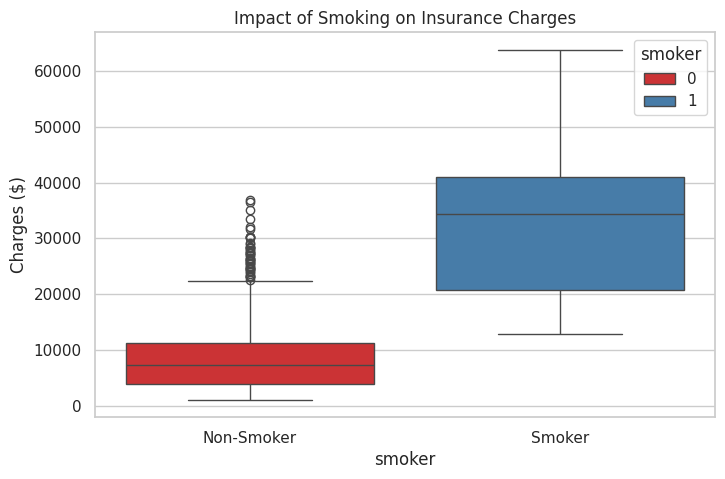

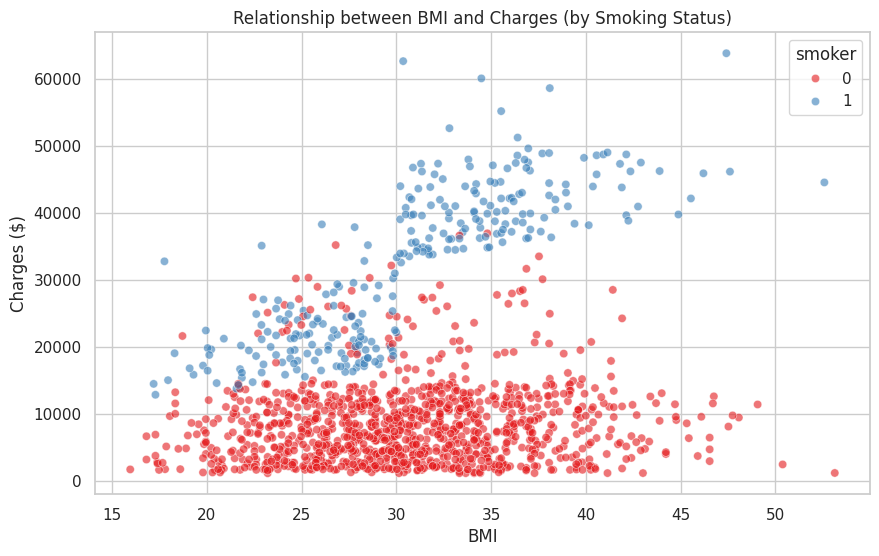

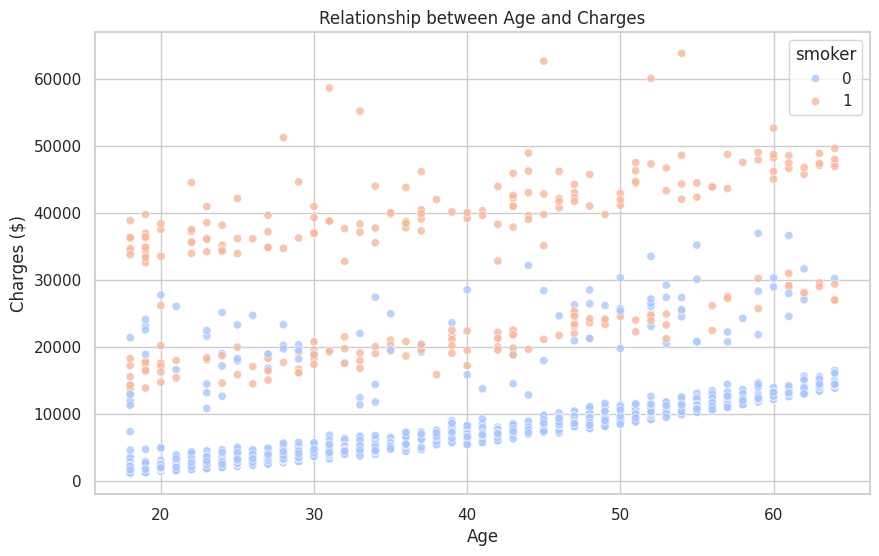

In [15]:
sns.set_theme(style="whitegrid")

# 1. Impact of Smoking on Charges (Box Plot)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='smoker', y='charges',hue='smoker', palette='Set1')
plt.title('Impact of Smoking on Insurance Charges')
plt.xticks([0, 1], ['Non-Smoker', 'Smoker'])
plt.ylabel('Charges ($)')
plt.show()

# 2. Impact of BMI on Charges (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6, palette='Set1')
plt.title('Relationship between BMI and Charges (by Smoking Status)')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.show()

# 3. Impact of Age on Charges (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.8, palette='coolwarm')
plt.title('Relationship between Age and Charges')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.show()

---

## 6. Model Training (Linear Regression)
We split the data into features (X) and target (y), then train a Linear Regression model.
* **Features:** Age, BMI, Children, Smoker, Sex, Region.
* **Target:** Charges.

In [16]:
# Define Features and Target
X = df.drop(columns=['charges'])
y = df['charges']

# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Linear Regression model trained successfully.
Intercept: -11092.652295945947
Coefficients: [  248.21072022  -101.54205399   318.70144095   533.0099888
 23077.76459287  -391.76145478  -838.91961573  -659.13975155]


---

## 7. Model Evaluation
We evaluate the performance of our regression model using standard error metrics:
* **MAE (Mean Absolute Error):** The average absolute difference between predicted and actual charges.
* **RMSE (Root Mean Squared Error):** Penalizes larger errors more heavily.
* **R² Score:** Explains how well the independent variables explain the variance in the target.

Mean Absolute Error (MAE): $4177.05
Root Mean Squared Error (RMSE): $5956.34
R² Score: 0.8069


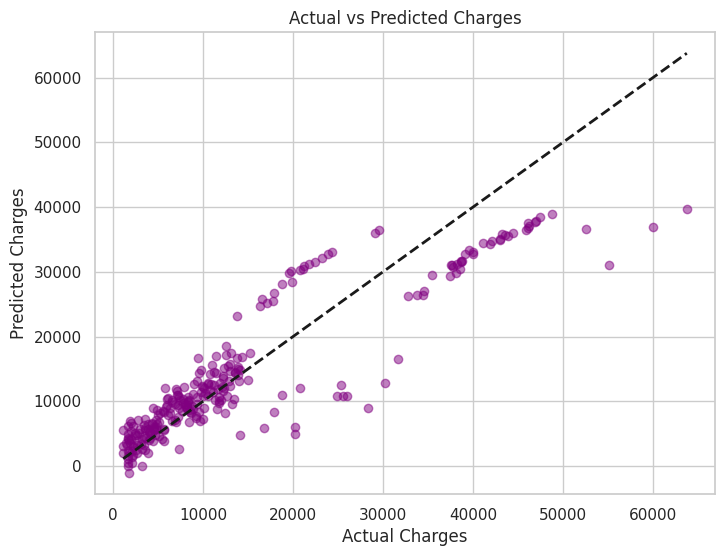

In [18]:
# Make predictions
y_pred = model.predict(X_test)

# Calculate Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print("="*40)

# Visualizing Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # Diagonal line
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Charges')
plt.show()

---

## 8. Conclusion
In this project, we successfully developed a regression model to estimate medical insurance costs.

**Key Insights:**
1.  **Smoking is the biggest factor:** The EDA clearly showed that smokers (encoded as 1) incur significantly higher charges than non-smokers. The scatter plot of BMI vs. Charges revealed two distinct clusters, with smokers forming the upper cluster of high costs.
2.  **BMI Correlation:** For non-smokers, BMI has a relatively low impact on charges. However, for smokers, an increase in BMI leads to a drastic increase in medical costs.
3.  **Age Trend:** Costs linearly increase with age, which is expected behavior.
4.  **Model Performance:** The Linear Regression model achieved a decent R² score (typically around 0.8), indicating it explains a large portion of the variance. However, the RMSE suggests there is still variability, likely because medical costs can be non-linear. Future improvements could involve using "Polynomial Regression" or "Random Forest Regressors" to capture these non-linear patterns.